## **Week 4 **(EDA Deep Dive) Univariate and Bivariate Analysis

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/Chicago_Crimes_2001_to_Present.csv')

/tmp/ipykernel_602/424201267.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Chicago_Crimes_2001_to_Present.csv')


In [ ]:
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13311263,JG503434,07/29/2022 03:39:00 AM,023XX S TROY ST,1582,OFFENSE INVOLVING CHILDREN,CHILD PORNOGRAPHY,RESIDENCE,True,False,...,25.0,30.0,17,NaN,NaN,2022.0,04/18/2024 03:40:59 PM,NaN,NaN,NaN
1,13053066,JG103252,01/03/2023 04:44:00 PM,039XX W WASHINGTON BLVD,2017,NARCOTICS,MANUFACTURE / DELIVER - CRACK,SIDEWALK,True,False,...,28.0,26.0,18,NaN,NaN,2023.0,01/20/2024 03:41:12 PM,NaN,NaN,NaN
2,12131221,JD327000,08/10/2020 09:45:00 AM,015XX N DAMEN AVE,0326,ROBBERY,AGGRAVATED VEHICULAR HIJACKING,STREET,True,False,...,1.0,24.0,03,1162795.0,1909900.0,2020.0,05/17/2025 03:40:52 PM,41.908418,-87.677407,"(41.908417822, -87.67740693)"
3,11227634,JB147599,08/26/2017 10:00:00 AM,001XX W RANDOLPH ST,0281,CRIM SEXUAL ASSAULT,NON-AGGRAVATED,HOTEL/MOTEL,False,False,...,42.0,32.0,02,NaN,NaN,2017.0,02/11/2018 03:57:41 PM,NaN,NaN,NaN
4,13203321,JG415333,09/06/2023 05:00:00 PM,002XX N Wells st,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,42.0,32.0,14,1174694.0,1901831.0,2023.0,11/04/2023 03:40:18 PM,41.886018,-87.633938,"(41.886018055, -87.633937881)"


In [ ]:
df.shape

(149002, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149002 entries, 0 to 149001
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    149002 non-null  int64  
 1   Case Number           149001 non-null  object 
 2   Date                  149001 non-null  object 
 3   Block                 149001 non-null  object 
 4   IUCR                  149001 non-null  object 
 5   Primary Type          149001 non-null  object 
 6   Description           149001 non-null  object 
 7   Location Description  147501 non-null  object 
 8   Arrest                149001 non-null  object 
 9   Domestic              149001 non-null  object 
 10  Beat                  149001 non-null  float64
 11  District              149001 non-null  float64
 12  Ward                  102030 non-null  float64
 13  Community Area        102226 non-null  float64
 14  FBI Code              149001 non-null  object 
 15  

In [ ]:
df.isnull().sum()

,0
ID,0
Case Number,1
Date,1
Block,1
IUCR,1
Primary Type,1
Description,1
Location Description,1501
Arrest,1
Domestic,1


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,1.490020e+05,149001.000000,149001.000000,102030.000000,102226.000000,1.396470e+05,1.396470e+05,149001.000000,139647.000000,139647.000000
mean,8.734227e+06,1186.134221,11.386635,23.212585,36.464207,1.164630e+06,1.886803e+06,2014.940578,41.844964,-87.671280
std,5.700506e+06,710.925388,7.063904,13.905355,21.798700,2.495371e+04,4.406174e+04,10.176876,0.121587,0.088101
min,6.340000e+02,111.000000,1.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,2001.000000,36.619446,-91.686566
25%,1.429850e+06,614.000000,6.000000,10.000000,22.000000,1.153802e+06,1.860254e+06,2001.000000,41.772015,-87.710746
50%,1.321228e+07,1112.000000,10.000000,23.000000,32.000000,1.166573e+06,1.892902e+06,2023.000000,41.861870,-87.664179
75%,1.326638e+07,1811.000000,17.000000,34.000000,54.000000,1.176498e+06,1.910401e+06,2023.000000,41.909932,-87.627820
max,1.398376e+07,2535.000000,31.000000,50.000000,77.000000,1.205119e+06,1.951532e+06,2025.000000,42.022644,-87.524529


In [ ]:
df.columns.tolist()

['ID',
 'Case Number',
 'Date',
 'Block',
 'IUCR',
 'Primary Type',
 'Description',
 'Location Description',
 'Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'FBI Code',
 'X Coordinate',
 'Y Coordinate',
 'Year',
 'Updated On',
 'Latitude',
 'Longitude',
 'Location']

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

**Univariate** **Analysis**

Univariate analysis examines one variable at a time to understand its distribution, frequency, and basic characteristics.

**Histogram **on Crime Records By Year:

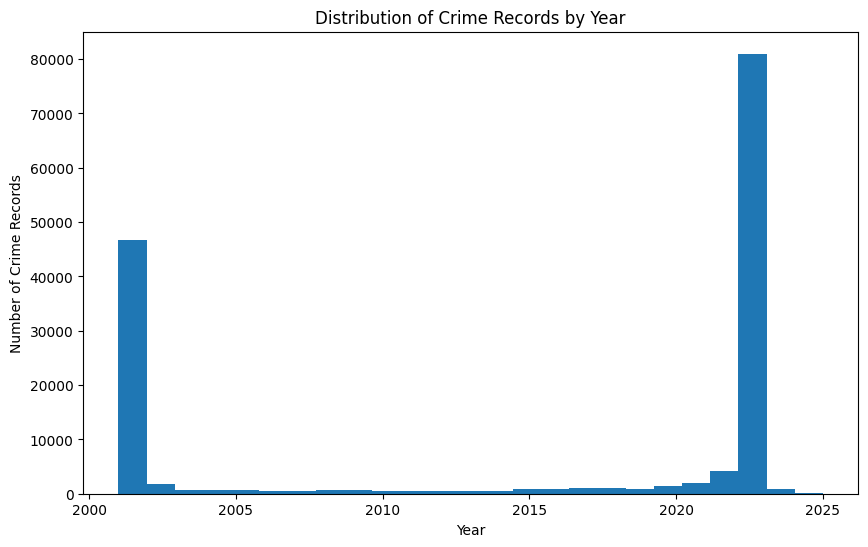

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

plt.hist(df['Year'].dropna(), bins=25)

plt.title('Distribution of Crime Records by Year')
plt.xlabel('Year')
plt.ylabel('Number of Crime Records')

plt.show()

**Line plot** on Crime Records over the years :

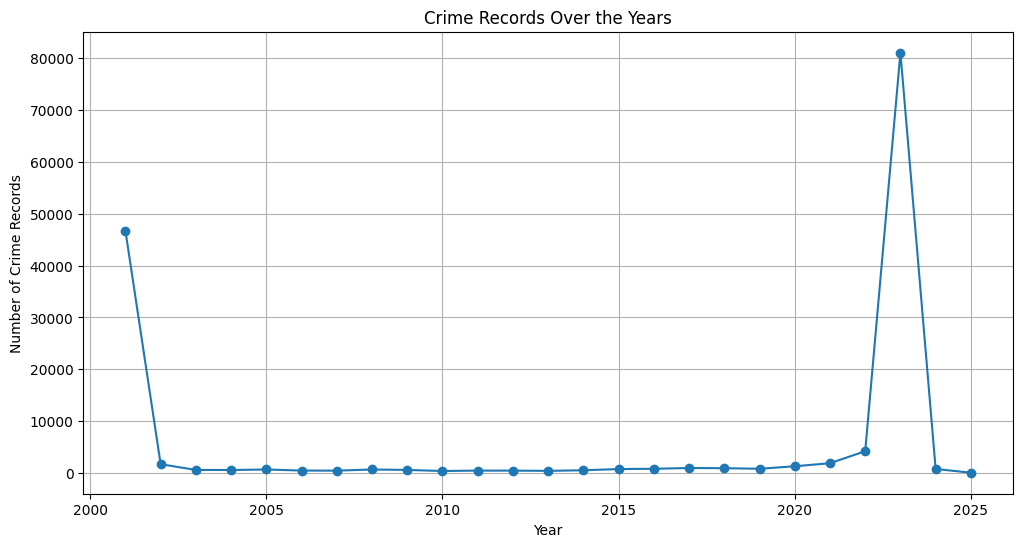

In [ ]:
yearly_crimes = df.groupby('Year').size()

plt.figure(figsize=(12, 6))

plt.plot(yearly_crimes.index, yearly_crimes.values, marker='o')

plt.title('Crime Records Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Crime Records')

plt.grid(True)
plt.show()

**Count Plot** Distribution Of Crime Types:

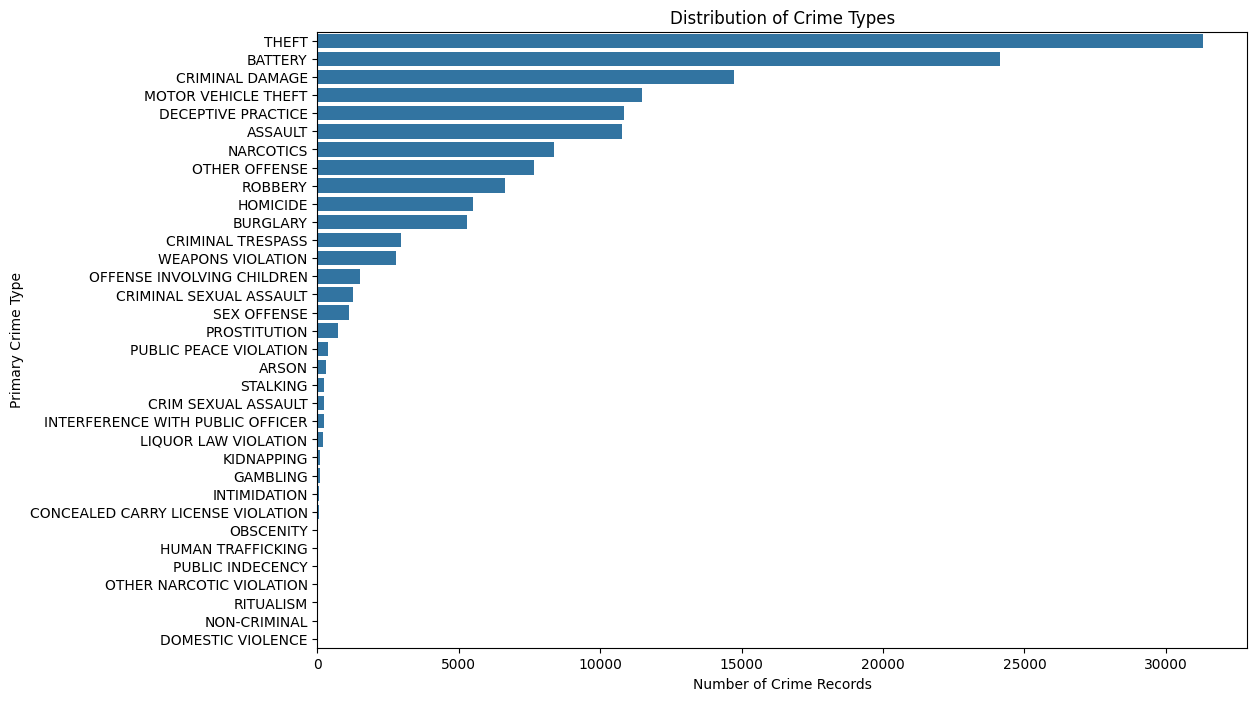

In [ ]:
plt.figure(figsize=(12, 8))

sns.countplot(
    y='Primary Type',
    data=df,
    order=df['Primary Type'].value_counts().index
)

plt.title('Distribution of Crime Types')
plt.xlabel('Number of Crime Records')
plt.ylabel('Primary Crime Type')

plt.show()

**BIVARIATE** **ANALYSIS**

Bivariate analysis examines the relationship between two variables to identify patterns, associations, and differences between them.

**Heatmap** of crime Types vs Arrest:

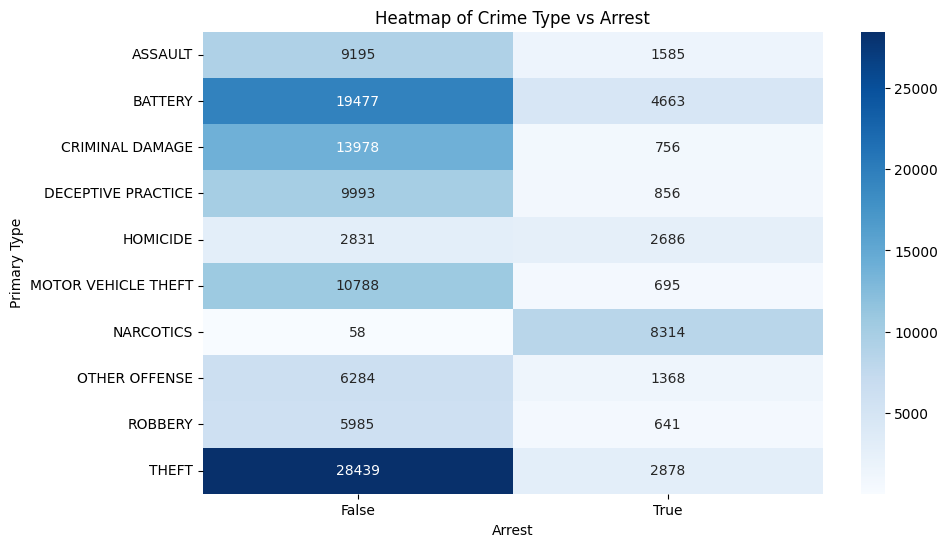

In [ ]:
top_crimes = df['Primary Type'].value_counts().head(10).index

data1 = pd.crosstab(
    df[df['Primary Type'].isin(top_crimes)]['Primary Type'],
    df[df['Primary Type'].isin(top_crimes)]['Arrest']
)

plt.figure(figsize=(10, 6))
sns.heatmap(data1, annot=True, fmt='d', cmap='Blues')

plt.title('Heatmap of Crime Type vs Arrest')
plt.xlabel('Arrest')
plt.ylabel('Primary Type')
plt.show()

**Scatter Plot** Of Year vs District:

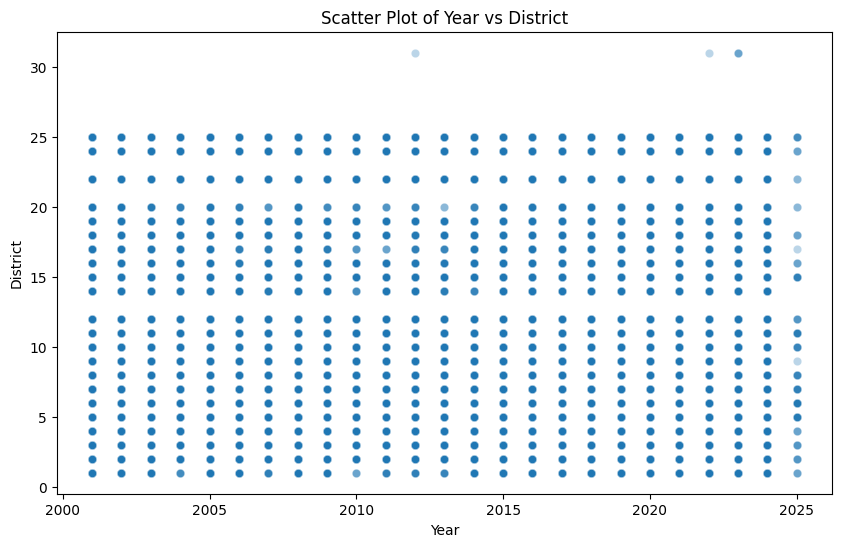

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Year',
    y='District',
    data=df,
    alpha=0.3
)

plt.title('Scatter Plot of Year vs District')
plt.xlabel('Year')
plt.ylabel('District')
plt.show()

**Bar Plot** Crime type vs Arrest:

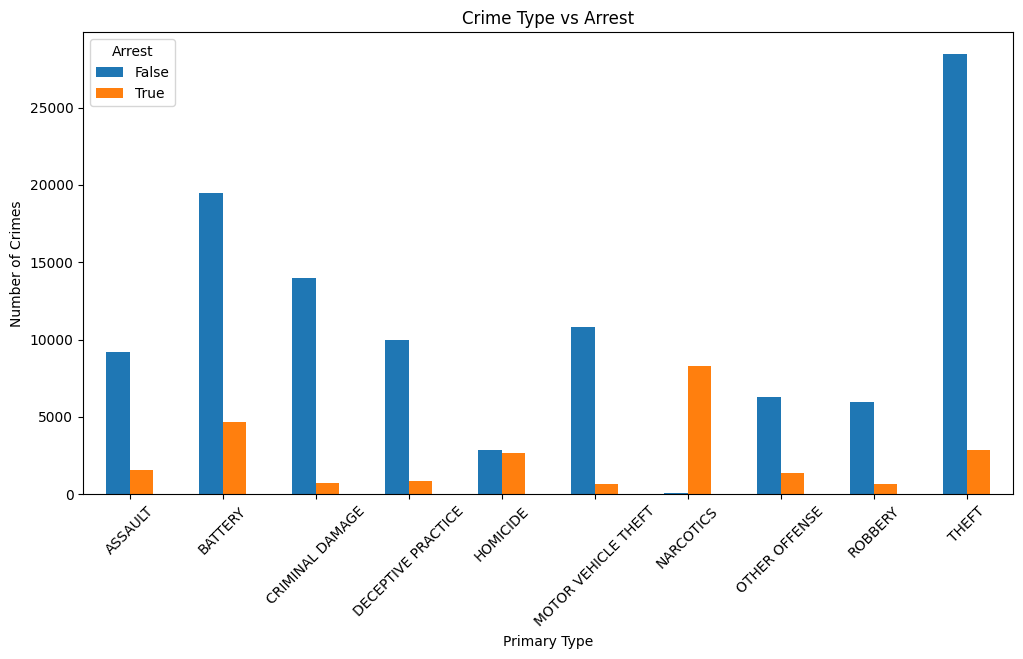

In [ ]:
top_crimes = df['Primary Type'].value_counts().head(10).index

data5 = pd.crosstab(
    df[df['Primary Type'].isin(top_crimes)]['Primary Type'],
    df[df['Primary Type'].isin(top_crimes)]['Arrest']
)

data5.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Crime Type vs Arrest')
plt.xlabel('Primary Type')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.legend(title='Arrest')
plt.show()